[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CityScope/UrbanAccessAnalyzer/blob/main/examples/green_areas.ipynb)

# 🌳 Green Space Accessibility

This notebook demonstrates using `UrbanAccessAnalyzer` to measure **walking
accessibility to green/open space** -- parks, gardens, forests, and grass
areas -- a common urban-planning and public-health metric (e.g. "share of
residents within a 10-minute walk of a park").

**POI kind used:** `"green_areas"`, one of the named kinds accepted by
`UrbanAccessAnalyzer.api.PointsOfInterest.from_overpass`. It queries OSM for
`leisure=park`, `leisure=garden`, `landuse=forest`, `landuse=grass`, and
`landuse=greenfield` features and merges/cleans them into walkable green-space
polygons (see `UrbanAccessAnalyzer.osm_io.green_areas`'s docstring for the
exact erosion/dilation cleanup it applies to drop slivers and merge adjacent
patches). This was verified against a real place (Davis Square, Somerville,
MA) before finalizing this notebook -- it reliably returns real park/green
polygons for a walkable urban area.

**How the score is computed:** exactly the same isochrone pipeline as
`examples/walkability.ipynb`, via
`UrbanAccessAnalyzer.api.compute_accessibility`: geocode the place -> build
the walking street network -> fetch green-area polygons (collapsed to a
representative point each) -> run `AccessibilityAnalyzer.run` to rank every
street segment by the closest walk-distance tier to a green area -- see
`UrbanAccessAnalyzer.isochrones.graph` for the tier-ranking methodology.

In [ ]:
# If using colab
# Takes around 1-2 min

# !pip install "UrbanAccessAnalyzer[plot] @ git+https://github.com/CityScope/UrbanAccessAnalyzer.git@v2.0.0"
# !pip install "geohierarchy @ git+https://github.com/CityScope/geohierarchy.git"
# !pip install "pycensus @ git+https://github.com/CityScope/pyCensus.git"

# Restart notebook after installing this if needed

In [1]:
import warnings

import matplotlib.pyplot as plt

from UrbanAccessAnalyzer import api

warnings.filterwarnings("ignore")  # geographic-CRS / centroid warnings from intermediate steps

## 1. Define the place and inputs

**Davis Square, Somerville, MA** is a dense residential/commercial
neighborhood with several nearby parks -- a good showcase for a green-space
accessibility gradient at walking scale.

- `distance_steps`: isochrone thresholds in meters, closest first. `400m`
  (~5 min walk), `800m` (~10 min), `1200m` (~15 min).

In [2]:
place = "Davis Square, Somerville, MA, USA"
poi_kind = "green_areas"
distance_steps = [400, 800, 1200]  # meters: ~5, ~10, ~15 minute walks
buffer = 600  # meters
pbf_path = "output/davis_square/region.osm.pbf"

## 2. Run the pipeline

One call: geocodes the AOI, builds the walking street network, fetches the
green-space POIs, and computes the walk-distance access score for every
street segment.

In [3]:
access_edges_gdf, aoi, points = api.compute_accessibility(
    place=place,
    poi_kind=poi_kind,
    pbf_path=pbf_path,
    buffer=buffer,
    network_type="walk",
    distance_steps=distance_steps,
    simplify_distance=20,
    max_dist=150,
    verbose=False,
)

print(f"{len(access_edges_gdf)} scored street segments, {len(points.df)} green-area POIs")
access_edges_gdf["access_score"].value_counts()

Fetching Geofabrik index from https://download.geofabrik.de/index-v1.json...


File 'output/davis_square/us_massachusetts.osm.pbf' already exists. Skipping download.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2817 scored street segments, 17 green-area POIs


access_score
3    1452
2    1001
1     364
Name: count, dtype: int64

## 3. Plot: green-space accessibility choropleth

`access_score` is ranked highest-for-closest (3 = within 400m, 2 = within
800m, 1 = within 1200m of the nearest green area). Darker/warmer segments
below are within a shorter walk of a park or other green space.

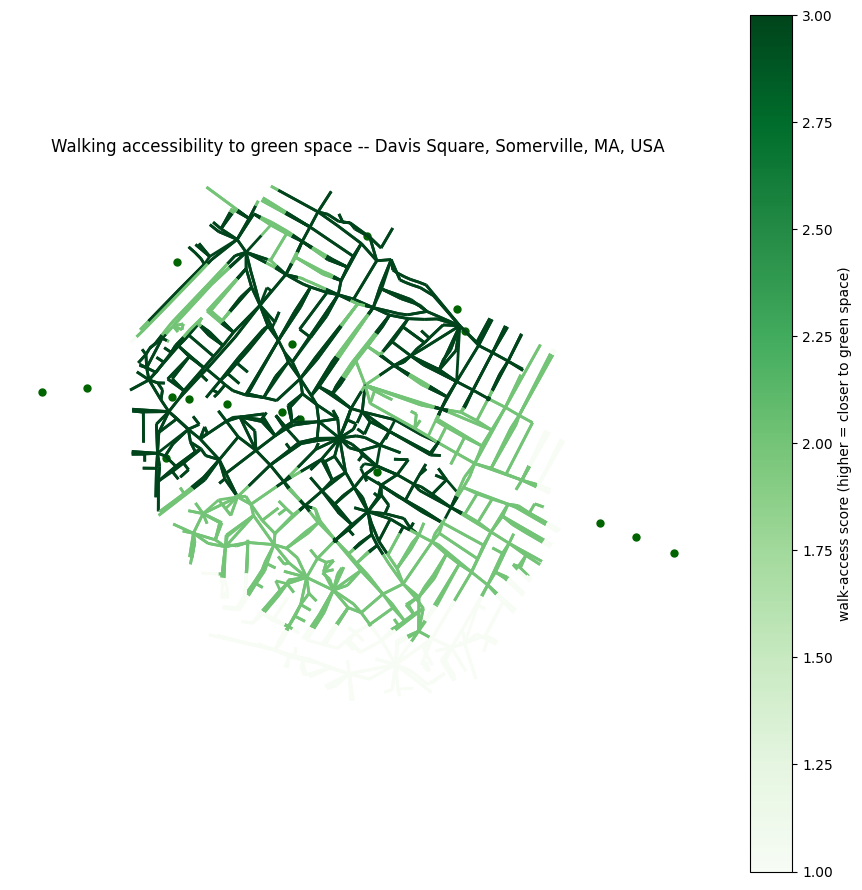

In [4]:
fig, ax = plt.subplots(figsize=(9, 9))
access_edges_gdf.plot(
    ax=ax,
    column="access_score",
    cmap="Greens",
    linewidth=2,
    legend=True,
    legend_kwds={"label": "walk-access score (higher = closer to green space)"},
)
points.to_gdf().to_crs(access_edges_gdf.crs).plot(ax=ax, color="darkgreen", markersize=25, label="green areas")
ax.set_title(f"Walking accessibility to green space -- {place}")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 4. Who actually lives near a park?

We use **`pycensus.worldwide.worldpop`** for population here rather than a
country-specific source like the US Census -- `UrbanAccessAnalyzer`
examples are meant to work for any place in the world, and WorldPop's
gridded 100m-resolution rasters (from the WorldPop Hub, no API key
required) cover the whole globe. We build an H3-cell grid over the AOI
(`geohierarchy.utils.h3_cells`) and rasterize WorldPop's population onto
it.

In [ ]:
import pycensus.worldwide.worldpop as worldpop

population_file = worldpop.download_worldpop_population(
    aoi.gdf,
    2025,
    folder="worldpop_cache",
    resolution="100m",
)

### 4.1 Build a `geohierarchy.GeoHierarchy` and map the joined result

An H3-cell grid is the hierarchy's single level; the street-level
`access_score` and the WorldPop raster are layered onto it as external
sources -- `add_vector_data(..., agg=Mean(), geoweight_by="length")` for
the score (streets are lines; average, don't sum, a 1-3 tier), and
`add_raster_data(..., agg=Sum())` for population (counts add up).

The result renders as an interactive `HierarchyMap` instead of a static
matplotlib choropleth -- pan/zoom, and click a cell to see its population
and mean access score in a popup.

In [ ]:
from geohierarchy import GeoHierarchy, Sum, Mean
from geohierarchy.maps.folium import HierarchyMap, ColorSpec
from geohierarchy.utils import h3_cells

h3_resolution = 9  # ~0.1 km2 hexagons -- fine enough for a neighborhood-scale AOI
h3_grid = h3_cells(aoi.gdf, resolution=h3_resolution)

hierarchy = GeoHierarchy()
hierarchy.add_level("h3", h3_grid, id_col="h3")
hierarchy.add_vector_data(
    access_edges_gdf,
    level="h3",
    columns=["access_score"],
    agg=Mean(),
    geoweight_by="length",
)
hierarchy.add_raster_data(population_file, column="population", level="h3", agg=Sum())

bg = hierarchy["h3"]
bg = bg[bg.intersects(aoi.gdf.union_all())]
bg.head()

In [ ]:
access_style = ColorSpec(column="access_score", cmap="Greens", domain=(1, 3))

result_map = HierarchyMap(hierarchy, levels=["h3"], tiles_dir="map_tiles")
result_map.configure_level(
    "h3",
    style=access_style,
    popup_fields=["population", "access_score"],
)
result_map.build()
result_map.save("result_map.html")

`HierarchyMap` serves geometry as vector tiles fetched over plain HTTP, so
(as with the pyCensus Boston walkthrough this pattern is borrowed from)
opening the saved HTML file directly (double-click / `file://`) will show
the basemap but silently fail to load geometry -- browsers block local
`fetch()` calls from a `file://` page. The cell below starts a tiny local
server so the map previews correctly inside this notebook; the same
requirement applies to wherever you host the two output files for real
(GitHub Pages works, a bare `file://` link does not).

In [ ]:
import functools
import http.server
import threading

from IPython.display import IFrame

PORT = 8001
handler = functools.partial(http.server.SimpleHTTPRequestHandler, directory=".")
httpd = http.server.ThreadingHTTPServer(("localhost", PORT), handler)
threading.Thread(target=httpd.serve_forever, daemon=True).start()

IFrame(f"http://localhost:{PORT}/result_map.html", width="100%", height=600)

### 4.2 Share of residents within each walk-tier

A population-weighted summary of the same join: what share of the AOI's
population lives in a block group whose *mean* access score is the best
tier (3, i.e. within 400m of a park)?

In [ ]:
share_best_tier = (
    bg.loc[bg["access_score"] >= 2.5, "population"].sum() / bg["population"].sum()
)
print(f"Roughly {share_best_tier:.0%} of the {bg['population'].sum():,.0f} people here live "
      f"in an area within a ~5 minute walk of green space.")